# 01 — Main Effect Overview

**Status: current, with a standing caveat.** Reads the active
`analyze_base`/`analyze_controls` GSM8K results plus the frozen Qwen dense
MATH-500 sweep.

Objective:
- Reproduce the geometry-vs-entropy gain at each condition's best combined layer.
- Show raw and length-controlled gains side by side, and the all-layers view.

**Read the length-controlled bars, not the raw ones.** These are *pooled,
all-trace* AUCs, which the 2026-07-18 truncation-bias audit showed are
length-confounded: on Qwen MATH-500 Best-of-8, trace length alone pools at AUC
0.737 but collapses to 0.478 within-prompt on parseable traces. The pooled view
is retained because it is the historical headline and the cross-condition
comparison is still informative — but it is *not* the current claim. The current
claim lives in `11_prompt_geometry_core_experiments` (within-prompt) and
`12_wave1_abstention` (between-prompt).

In [5]:
from __future__ import annotations

import sys
from pathlib import Path

candidate_dirs = [Path.cwd(), Path.cwd() / "notebooks", *[parent / "notebooks" for parent in Path.cwd().parents]]
for candidate in candidate_dirs:
    if (candidate / "_viz_utils.py").exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError("Could not locate notebooks/_viz_utils.py from current working directory")

import matplotlib.pyplot as plt
import numpy as np

import _viz_utils as vu

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


In [6]:
all_results = vu.load_all_results()
layer_rows = vu.collect_layer_rows(all_results)
best_rows = vu.collect_best_layer_rows(layer_rows)

model_order = {"qwen": 0, "qwen_dense": 1}
dataset_order = {"math500": 0, "gsm8k": 1}
best_rows = sorted(best_rows, key=lambda r: (model_order.get(r["model"], 99), dataset_order.get(r["dataset"], 99), r["layer"]))

labels = [vu.condition_label(r["model"], r["dataset"]) + f" (L{r['layer']})" for r in best_rows]
entropy = np.array([r["entropy_auc"] for r in best_rows], dtype=float)
mahal = np.array([r["mahal_auc"] for r in best_rows], dtype=float)
combined = np.array([r["combined_auc"] for r in best_rows], dtype=float)
raw_delta = np.array([r["delta_raw"] for r in best_rows], dtype=float)
len_delta = np.array([r["delta_len_ctrl"] for r in best_rows], dtype=float)


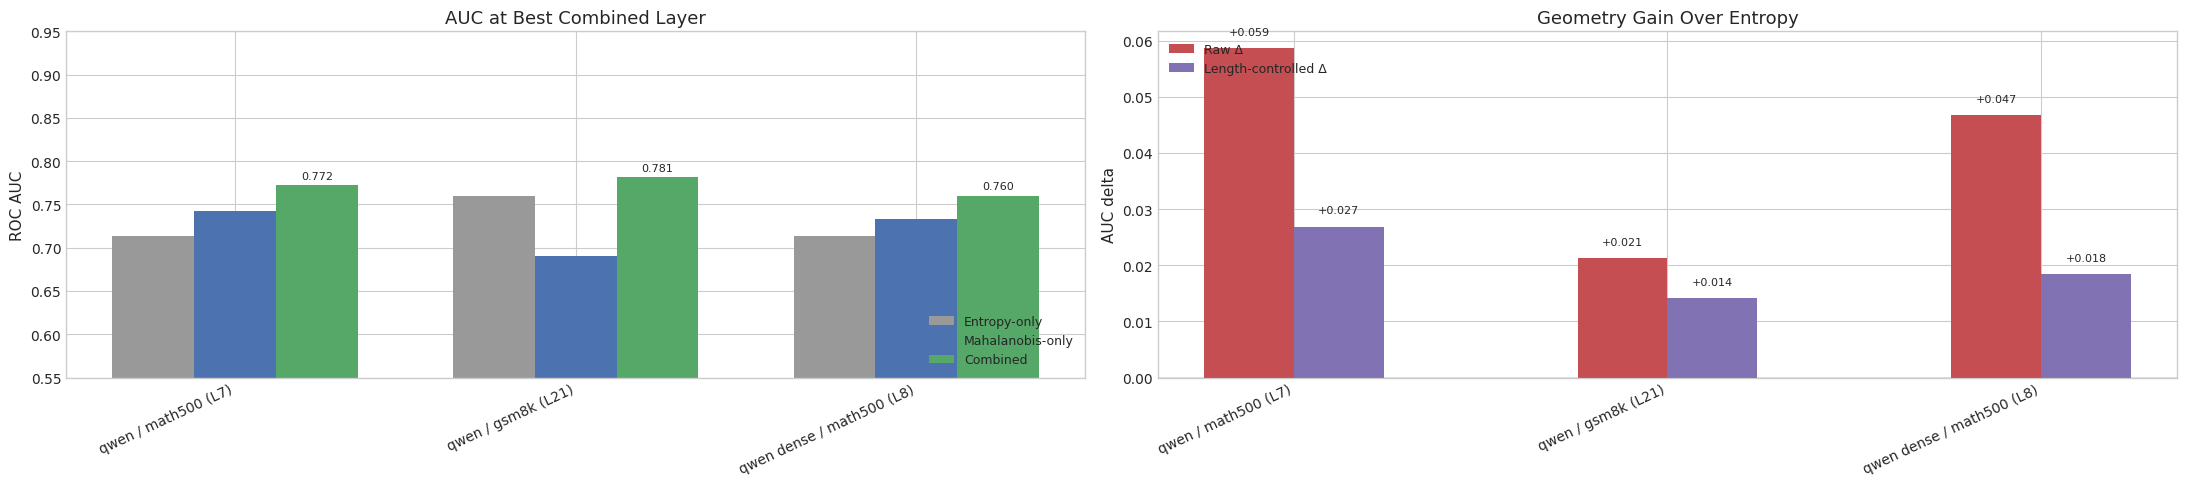

In [7]:
x = np.arange(len(labels))
width = 0.24

fig, axes = plt.subplots(1, 2, figsize=(22, 5))

bar_ent = axes[0].bar(x - width, entropy, width=width, label="Entropy-only", color="#999999")
bar_mah = axes[0].bar(x, mahal, width=width, label="Mahalanobis-only", color="#4C72B0")
bar_comb = axes[0].bar(x + width, combined, width=width, label="Combined", color="#55A868")
axes[0].set_title("AUC at Best Combined Layer")
axes[0].set_ylabel("ROC AUC")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha="right")
axes[0].legend(loc="lower right")
axes[0].set_ylim(0.55, 0.95)

# Value labels on combined bars only (the main claim)
for bar in bar_comb:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

bar_raw = axes[1].bar(x - width / 2, raw_delta, width=width, label="Raw Δ", color="#C44E52")
bar_len = axes[1].bar(x + width / 2, len_delta, width=width, label="Length-controlled Δ", color="#8172B3")
axes[1].axhline(0.0, color="black", linewidth=1, alpha=0.5)
axes[1].set_title("Geometry Gain Over Entropy")
axes[1].set_ylabel("AUC delta")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].legend(loc="upper left")

for bar in bar_raw:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                 f"+{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bar_len:
    v = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + (0.002 if v >= 0 else -0.006),
                 f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

fig.tight_layout()
plt.show()


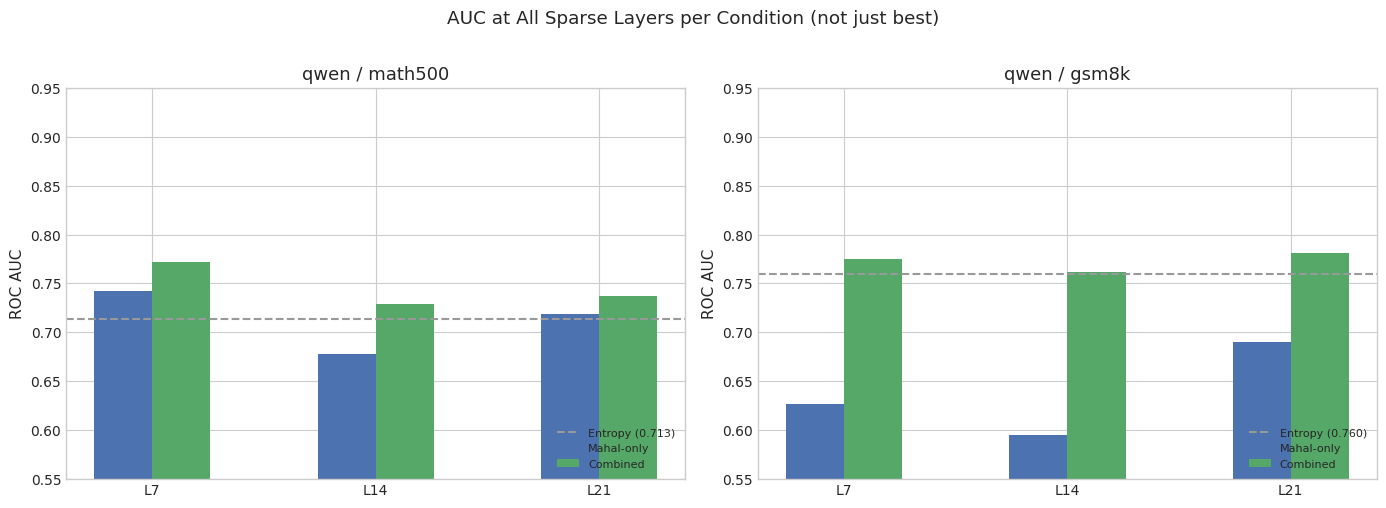

In [8]:
# All-layers view for the active Qwen conditions (addresses best-layer selection bias).
# Each subplot uses the model's own layer indices, detected from data.
main_conditions = [("qwen", "math500"), ("qwen", "gsm8k")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
axes = axes.ravel()

for ax, (model, dataset) in zip(axes, main_conditions):
    rows = {r["layer"]: r for r in layer_rows if r["model"] == model and r["dataset"] == dataset}
    if not rows:
        ax.set_visible(False)
        continue
    layer_list = sorted(rows.keys())
    entropy_val = next(iter(rows.values()))["entropy_auc"]

    x = np.arange(len(layer_list))
    width = 0.26
    mahal_vals = [rows[l]["mahal_auc"] for l in layer_list]
    combined_vals = [rows[l]["combined_auc"] for l in layer_list]

    ax.bar(x - width / 2, mahal_vals, width=width, label="Mahal-only", color="#4C72B0")
    ax.bar(x + width / 2, combined_vals, width=width, label="Combined", color="#55A868")
    ax.axhline(entropy_val, linestyle="--", color="#999999", linewidth=1.5, label=f"Entropy ({entropy_val:.3f})")

    ax.set_title(vu.condition_label(model, dataset))
    ax.set_xticks(x)
    ax.set_xticklabels([f"L{l}" for l in layer_list])
    ax.set_ylabel("ROC AUC")
    ax.set_ylim(0.55, 0.95)
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("AUC at All Sparse Layers per Condition (not just best)", y=1.01)
fig.tight_layout()
plt.show()
